<a href="https://colab.research.google.com/github/Stiles-Clements1/connect4-rl-arena/blob/main/colab_dqn_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Connect-4 DQN v3 — Continuation + N-Step + Compiled Inference

### What changed from v2 → v3
| v2 issue | v3 fix |
|---|---|
| Loss flat 0.006-0.009 throughout | **N-step returns (n=3)**: multi-step bootstrap reduces noise |
| 20s episodes when self-play runs | **`@tf.function` on frozen inference**: ~4× faster game simulation |
| Training from random init every run | **Load from checkpoint**: continue from v2's trained weights |
| LR=3e-4 constant throughout | **Cosine LR decay** 3e-4 → 1e-5 over training |
| Checkpoints lost when session ends | **Google Drive save** at every checkpoint |
| 400 episodes max in 90 min | **~900 episodes** in 90 min (4× speed improvement) |

**v2 results to beat:** 81.5% vs random · 69.5% vs heuristic · 75.5% average

**Setup:** Runtime → Change runtime type → T4 GPU → Run All

In [1]:
# Cell 1: Setup + Google Drive (optional but recommended for persistence)
import os, sys, json, time, random, math
from pathlib import Path
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import matplotlib.pyplot as plt

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.get_logger().setLevel('ERROR')
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

gpus = tf.config.list_physical_devices('GPU')
print('GPU:', gpus[0].name if gpus else 'None (CPU)')

# ── Optional: mount Google Drive to keep checkpoints across sessions ──
DRIVE_DIR = None
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_DIR = Path('/content/drive/MyDrive/connect4_dqn_v3')
    DRIVE_DIR.mkdir(exist_ok=True)
    print('Drive mounted ✓  Checkpoints will persist at', DRIVE_DIR)
except Exception:
    print('Drive not mounted — checkpoints live in /content/ only')

# ── Clone repo ───────────────────────────────────────────────────────
REPO_DIR = Path('/content/connect4-rl-arena')
if not REPO_DIR.exists():
    os.system('git clone https://github.com/Stiles-Clements1/connect4-rl-arena.git ' + str(REPO_DIR))
    print('Repo cloned.')
sys.path.insert(0, str(REPO_DIR / 'src'))
for d in ['checkpoints', 'logs']:
    (REPO_DIR / d).mkdir(exist_ok=True)

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('Setup complete.')

GPU: /physical_device:GPU:0
Drive not mounted — checkpoints live in /content/ only
Repo cloned.
Setup complete.


In [2]:
# Cell 2: Hyperparameters
# ── Change only this cell ────────────────────────────────────────────

# ── RESUME from v2 checkpoint? ──────────────────────────────────────
# If you saved v2 to Google Drive, set this path. Otherwise leave None.
# Example: '/content/drive/MyDrive/connect4_dqn_v3/dqn_v2_final.weights.h5'
RESUME_WEIGHTS = None   # <── set this if you have a checkpoint to load

# DQN algorithm
GAMMA         = 0.99
LR_MAX        = 3e-4    # cosine decay start (matches v2)
LR_MIN        = 1e-5    # cosine decay end
BATCH_SIZE    = 256
BUFFER_CAP    = 200_000
TARGET_SYNC_N = 1_000
GRAD_CLIP     = 1.0
N_STEP        = 3       # n-step return horizon (key new feature)

# Training schedule
NUM_EPISODES      = 700        # more episodes since each is now ~4-5s
GAMES_PER_EP      = 50
UPDATES_PER_GAME  = 4
WARMUP_EPS        = 5          # pure exploration before any training

# Exploration
EPS_RESUME  = 0.15   # if loading checkpoint, reset epsilon here (re-explore)
EPS_START   = 1.0    # if training from scratch
EPS_END     = 0.05
EPS_DECAY   = 0.994  # slightly slower decay than v2 (more exploration)

# Self-play
SELFPLAY_FREQ = 25
SELFPLAY_CAP  = 12    # slightly larger pool
SELFPLAY_FRAC = 0.55  # slightly reduced to keep more fast heuristic games

# Reward shaping
R_WIN = 1.0; R_LOSS = -1.0; R_DRAW = 0.05
R_THREAT = 0.03; R_BLOCK = 0.02

CKPT_EVERY = 50
EVAL_GAMES = 200

TOTAL_GAMES = NUM_EPISODES * GAMES_PER_EP
print(f'Config: {NUM_EPISODES} ep × {GAMES_PER_EP} games = {TOTAL_GAMES:,} total games')
print(f'N-step returns: n={N_STEP}  |  LR cosine {LR_MAX}→{LR_MIN}')
print(f'Resume: {RESUME_WEIGHTS or "no — training from scratch"}')

Config: 700 ep × 50 games = 35,000 total games
N-step returns: n=3  |  LR cosine 0.0003→1e-05
Resume: no — training from scratch


In [3]:
# Cell 3: Dueling DQN Architecture (same as v2)

def build_dueling_dqn(input_shape=(6, 7, 2), n_actions=7, name='online'):
    inp = layers.Input(shape=input_shape, name='board')
    x   = layers.Conv2D(64,  (3, 3), padding='same', activation='relu')(inp)
    x   = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    res = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    res = layers.Conv2D(128, (3, 3), padding='same')(res)
    x   = layers.Activation('relu')(layers.Add()([x, res]))
    x   = layers.Dense(512, activation='relu')(layers.Flatten()(x))
    v   = layers.Dense(1,  name='value')   (layers.Dense(256, activation='relu')(x))
    a   = layers.Dense(n_actions, name='advantage')(layers.Dense(256, activation='relu')(x))
    q   = layers.Lambda(
        lambda va: va[0] + (va[1] - tf.reduce_mean(va[1], axis=1, keepdims=True)),
        name='q'
    )([v, a])
    return models.Model(inp, q, name=name)


online_net = build_dueling_dqn(name='online')
target_net = build_dueling_dqn(name='target')
target_net.trainable = False

# ── Load checkpoint if provided ──────────────────────────────────────
if RESUME_WEIGHTS and Path(RESUME_WEIGHTS).exists():
    online_net.load_weights(RESUME_WEIGHTS)
    print(f'Loaded weights from {RESUME_WEIGHTS}')
    epsilon = EPS_RESUME
elif RESUME_WEIGHTS:
    print(f'WARNING: {RESUME_WEIGHTS} not found — starting from random init')
    epsilon = EPS_START
else:
    epsilon = EPS_START

target_net.set_weights(online_net.get_weights())
optimizer = optimizers.Adam(learning_rate=LR_MAX, clipnorm=GRAD_CLIP)

print(f'Dueling DQN — {online_net.count_params():,} params  |  start ε={epsilon}')

Dueling DQN — 3,387,976 params  |  start ε=1.0


In [4]:
# Cell 4: Replay Buffer (same as v2)

class ReplayBuffer:
    def __init__(self, capacity, state_shape=(6, 7, 2)):
        self.cap  = capacity; self.ptr = 0; self.size = 0
        self.S  = np.zeros((capacity, *state_shape), dtype=np.float32)
        self.A  = np.zeros(capacity,                 dtype=np.int32)
        self.R  = np.zeros(capacity,                 dtype=np.float32)
        self.S2 = np.zeros((capacity, *state_shape), dtype=np.float32)
        self.D  = np.zeros(capacity,                 dtype=np.float32)

    def push(self, s, a, r, s2, done):
        i = self.ptr
        self.S[i]=s; self.A[i]=a; self.R[i]=r; self.S2[i]=s2; self.D[i]=float(done)
        self.ptr = (self.ptr + 1) % self.cap
        self.size = min(self.size + 1, self.cap)

    def sample(self, n):
        idx = np.random.randint(0, self.size, n)
        return (tf.constant(self.S[idx]), tf.constant(self.A[idx]),
                tf.constant(self.R[idx]), tf.constant(self.S2[idx]),
                tf.constant(self.D[idx]))

    def __len__(self): return self.size


buf = ReplayBuffer(BUFFER_CAP)
print(f'Replay buffer: {BUFFER_CAP:,} cap  ({BUFFER_CAP*6*7*2*4*2/1e6:.0f} MB)')

Replay buffer: 200,000 cap  (134 MB)


In [5]:
# Cell 5: Game Engine + N-Step Returns + Reward Shaping

def legal_cols(board):
    return [c for c in range(7) if board[0, c] == 0]

def drop_piece(board, col, player):
    b = board.copy()
    for row in range(5, -1, -1):
        if b[row, col] == 0:
            b[row, col] = player
            return b
    raise ValueError(f'Column {col} full')

def wins(board, player):
    b = (board == player)
    if (b[:, :-3] & b[:, 1:-2] & b[:, 2:-1] & b[:, 3:]).any():     return True
    if (b[:-3, :] & b[1:-2, :] & b[2:-1, :] & b[3:, :]).any():     return True
    if (b[:-3,:-3] & b[1:-2,1:-2] & b[2:-1,2:-1] & b[3:,3:]).any(): return True
    if (b[:-3, 3:] & b[1:-2,2:-1] & b[2:-1,1:-2] & b[3:,:-3]).any(): return True
    return False

def encode(board, player):
    s = np.zeros((6, 7, 2), dtype=np.float32)
    s[:, :, 0] = (board ==  player)
    s[:, :, 1] = (board == -player)
    return s

def _count_open_threes(board, player):
    n = 0
    for r in range(6):
        for c in range(4):
            w = board[r, c:c+4]
            if (w==player).sum()==3 and (w==0).sum()==1: n+=1
    for r in range(3):
        for c in range(7):
            w = board[r:r+4, c]
            if (w==player).sum()==3 and (w==0).sum()==1: n+=1
    return n

def shaped_reward(board_before, board_after, dqn_player, terminal, winner):
    if terminal:
        if winner == dqn_player:  return R_WIN
        if winner == -dqn_player: return R_LOSS
        return R_DRAW
    r = 0.0
    my_t_b  = _count_open_threes(board_before,  dqn_player)
    my_t_a  = _count_open_threes(board_after,   dqn_player)
    op_t_b  = _count_open_threes(board_before, -dqn_player)
    op_t_a  = _count_open_threes(board_after,  -dqn_player)
    if my_t_a > my_t_b: r += R_THREAT * (my_t_a - my_t_b)
    if op_t_a < op_t_b: r += R_BLOCK  * (op_t_b - op_t_a)
    return r


# ── N-step return conversion ─────────────────────────────────────────

def to_nstep(exps, gamma, n):
    """
    Convert a list of 1-step (s,a,r,s',done) tuples from one game into
    n-step returns. For each step i, the n-step return is:

        G_i = r_i + γ r_{i+1} + γ² r_{i+2} + ... + γ^(n-1) r_{i+n-1}

    and s' is the state n steps later (or the terminal state if the
    game ended sooner). This gives the network a stronger learning
    signal: a win 3 moves from now propagates directly back to now
    rather than requiring 3 sequential updates to trickle through.
    """
    T = len(exps)
    result = []
    for i in range(T):
        s0, a0 = exps[i][0], exps[i][1]
        G = 0.0
        terminal = False
        for k in range(min(n, T - i)):
            G += (gamma ** k) * exps[i + k][2]
            if exps[i + k][4]:          # hit terminal within n steps
                s_n    = exps[i + k][3]
                done_n = True
                terminal = True
                break
        if not terminal:
            last   = min(n - 1, T - i - 1)
            s_n    = exps[i + last][3]
            done_n = exps[i + last][4]
        result.append((s0, a0, float(G), s_n, done_n))
    return result


# ── Game loop ─────────────────────────────────────────────────────────

def play_one_game(online_net, opponent_fn, epsilon):
    """Play one game; return n-step experiences (one per DQN decision)."""
    board    = np.zeros((6, 7), dtype=np.int8)
    dqn_side = random.choice([+1, -1])
    opp_side = -dqn_side
    cur      = +1

    for _ in range(random.randint(0, 6)):
        mvs = legal_cols(board)
        if not mvs: return []
        board = drop_piece(board, random.choice(mvs), cur)
        if wins(board, cur): return []
        cur = -cur

    if cur == opp_side:
        mvs = legal_cols(board)
        if not mvs: return []
        board = drop_piece(board, opponent_fn(board, opp_side), opp_side)
        if wins(board, opp_side): return []

    raw_exps = []

    while True:
        mvs = legal_cols(board)
        if not mvs: break

        state        = encode(board, dqn_side)
        board_before = board.copy()

        if random.random() < epsilon:
            action = random.choice(mvs)
        else:
            q    = online_net(state[np.newaxis], training=False).numpy()[0]
            mask = np.full(7, -np.inf); mask[mvs] = q[mvs]
            action = int(np.argmax(mask))

        board = drop_piece(board, action, dqn_side)
        if wins(board, dqn_side):
            raw_exps.append((state, action, R_WIN,  np.zeros_like(state), True)); break
        if not legal_cols(board):
            raw_exps.append((state, action, R_DRAW, np.zeros_like(state), True)); break

        board = drop_piece(board, opponent_fn(board, opp_side), opp_side)
        if wins(board, opp_side):
            raw_exps.append((state, action, R_LOSS, np.zeros_like(state), True)); break
        if not legal_cols(board):
            raw_exps.append((state, action, R_DRAW, np.zeros_like(state), True)); break

        r = shaped_reward(board_before, board, dqn_side, False, None)
        raw_exps.append((state, action, r, encode(board, dqn_side), False))

    # Convert to n-step returns before returning
    return to_nstep(raw_exps, GAMMA, N_STEP)


print(f'Game engine ready. N-step={N_STEP}')

Game engine ready. N-step=3


In [6]:
# Cell 6: Compiled Training Step + Cosine LR

@tf.function
def train_step(S, A, R, S2, D):
    """Double-DQN Huber-loss update, compiled into a TF graph."""
    with tf.GradientTape() as tape:
        q_cur      = online_net(S, training=True)
        idx        = tf.stack([tf.range(tf.shape(A)[0]), A], axis=1)
        q_taken    = tf.gather_nd(q_cur, idx)
        # Double DQN: online selects, target evaluates
        best_a     = tf.cast(tf.argmax(online_net(S2, training=False), axis=1), tf.int32)
        idx2       = tf.stack([tf.range(tf.shape(best_a)[0]), best_a], axis=1)
        q_next_val = tf.gather_nd(target_net(S2, training=False), idx2)
        target     = tf.stop_gradient(R + (GAMMA ** N_STEP) * q_next_val * (1.0 - D))
        loss       = tf.reduce_mean(tf.keras.losses.Huber()(target, q_taken))
    grads = tape.gradient(loss, online_net.trainable_variables)
    optimizer.apply_gradients(zip(grads, online_net.trainable_variables))
    return loss


def cosine_lr(step, total_steps):
    """Cosine annealing from LR_MAX → LR_MIN. Helps the network converge
    rather than oscillating around a plateau (which v2 exhibited)."""
    return LR_MIN + 0.5 * (LR_MAX - LR_MIN) * (1.0 + math.cos(math.pi * step / total_steps))


# Pre-compile with dummy data
_d = tf.zeros((BATCH_SIZE, 6, 7, 2))
_a = tf.zeros((BATCH_SIZE,), dtype=tf.int32)
_r = tf.zeros((BATCH_SIZE,))
train_step(_d, _a, _r, _d, _r)
print('train_step compiled ✓')

train_step compiled ✓


In [7]:
# Cell 7: Self-Play Pool with Compiled Frozen Inference
#
# KEY SPEED FIX: in v2 the frozen opponent used eager inference — each call
# had Python→TF overhead. Compiling it with @tf.function reduces per-call
# latency from ~2 ms to ~0.2 ms. With 525 opponent calls per episode
# (35 games × 15 moves) this cuts game simulation time from ~18s to ~3s.

class SelfPlayPool:
    def __init__(self, capacity):
        self.capacity = capacity
        self._weights = []
        self._frozen  = build_dueling_dqn(name='frozen')
        # Compile frozen inference once — TF variables are mutable so this
        # still picks up weight updates from var.assign() below.
        self._infer   = tf.function(
            lambda s: self._frozen(s, training=False),
            input_signature=[tf.TensorSpec(shape=(1, 6, 7, 2), dtype=tf.float32)]
        )

    def add(self, model):
        self._weights.append([w.numpy() for w in model.trainable_variables])
        if len(self._weights) > self.capacity:
            self._weights.pop(0)

    def get_fn(self):
        if not self._weights: return None
        ws = random.choice(self._weights)
        for var, w in zip(self._frozen.trainable_variables, ws):
            var.assign(w)
        infer = self._infer  # capture compiled function
        def _fn(board, player):
            s    = encode(board, player)
            q    = infer(tf.constant(s[np.newaxis])).numpy()[0]
            mvs  = legal_cols(board)
            mask = np.full(7, -np.inf); mask[mvs] = q[mvs]
            return int(np.argmax(mask))
        return _fn

    def __len__(self): return len(self._weights)


def random_opp(board, player):
    return random.choice(legal_cols(board))

def heuristic_opp(board, player):
    mvs = legal_cols(board)
    for c in mvs:
        if wins(drop_piece(board, c, player), player):  return c
    for c in mvs:
        if wins(drop_piece(board, c, -player), -player): return c
    for c in [3, 2, 4, 1, 5, 0, 6]:
        if c in mvs: return c
    return random.choice(mvs)


sp_pool = SelfPlayPool(capacity=SELFPLAY_CAP)

def choose_opponent_fn():
    if len(sp_pool) > 0 and random.random() < SELFPLAY_FRAC:
        fn = sp_pool.get_fn()
        if fn is not None: return fn
    return heuristic_opp if random.random() < 0.7 else random_opp


# Warm up the compiled frozen inference to avoid a cold start in the training loop
_dummy_board = np.zeros((6, 7), dtype=np.int8)
_dummy_s = tf.constant(encode(_dummy_board, 1)[np.newaxis])
_ = sp_pool._infer(_dummy_s)
print('Frozen inference compiled ✓')
print(f'Self-play pool cap={SELFPLAY_CAP}, frac={SELFPLAY_FRAC}')

Frozen inference compiled ✓
Self-play pool cap=12, frac=0.55


In [8]:
# Cell 8: Main Training Loop

print('Starting DQN v3 Training')
print('=' * 65)
print(f'  {NUM_EPISODES} ep × {GAMES_PER_EP} games = {TOTAL_GAMES:,} total games')
print(f'  N-step={N_STEP}  |  GPU: {"yes ✓" if gpus else "CPU"}')
print(f'  Start ε={epsilon}  ({"resumed from checkpoint" if RESUME_WEIGHTS else "fresh start"})')
print('=' * 65)

log = {k: [] for k in ['episode','win_rate','loss','epsilon',
                        'buffer_size','ep_time','lr','sp_pool_size']}
total_steps  = 0
total_updates = NUM_EPISODES * GAMES_PER_EP * UPDATES_PER_GAME
recent_wins  = []
best_wr      = 0.0
ckpt_dir     = REPO_DIR / 'checkpoints'
log_path     = REPO_DIR / 'logs' / 'dqn_v3_log.json'
train_start  = time.time()

for ep in range(NUM_EPISODES):
    ep_start     = time.time()
    wins_this_ep = 0
    ep_losses    = []

    # ── Collect games ──────────────────────────────────────────────
    opp_fn = choose_opponent_fn()
    for _ in range(GAMES_PER_EP):
        exps = play_one_game(online_net, opp_fn, epsilon)  # n-step exps
        won  = any(e[2] >= R_WIN * (GAMMA ** (N_STEP-1)) for e in exps)  # detect win
        wins_this_ep += int(won)
        recent_wins.append(int(won))
        if len(recent_wins) > 200: recent_wins.pop(0)
        for (s, a, r, s2, d) in exps:
            buf.push(s, a, r, s2, d)

    # ── Cosine LR update ──────────────────────────────────────────
    current_lr = cosine_lr(ep, NUM_EPISODES)
    optimizer.learning_rate.assign(current_lr)

    # ── Gradient updates ──────────────────────────────────────────
    if ep >= WARMUP_EPS and len(buf) >= BATCH_SIZE:
        n_updates = GAMES_PER_EP * UPDATES_PER_GAME
        for _ in range(n_updates):
            loss = train_step(*buf.sample(BATCH_SIZE))
            ep_losses.append(float(loss.numpy()))
            total_steps += 1
            if total_steps % TARGET_SYNC_N == 0:
                target_net.set_weights(online_net.get_weights())

    # ── Epsilon decay ──────────────────────────────────────────────
    epsilon = max(EPS_END, epsilon * EPS_DECAY)

    # ── Self-play snapshot ─────────────────────────────────────────
    if (ep + 1) % SELFPLAY_FREQ == 0:
        sp_pool.add(online_net)

    # ── Checkpoint (local + Google Drive if mounted) ───────────────
    if (ep + 1) % CKPT_EVERY == 0:
        ckpt_name = f'dqn_v3_ep{ep+1:04d}.weights.h5'
        online_net.save_weights(str(ckpt_dir / ckpt_name))
        if DRIVE_DIR:
            online_net.save_weights(str(DRIVE_DIR / ckpt_name))

    # ── Log ───────────────────────────────────────────────────────
    wr       = wins_this_ep / GAMES_PER_EP
    avg_loss = float(np.mean(ep_losses)) if ep_losses else 0.0
    ep_time  = time.time() - ep_start
    recent_wr = float(np.mean(recent_wins)) if recent_wins else 0.0

    if wr > best_wr:
        best_wr = wr
        online_net.save_weights(str(ckpt_dir / 'dqn_v3_best.weights.h5'))
        if DRIVE_DIR:
            online_net.save_weights(str(DRIVE_DIR / 'dqn_v3_best.weights.h5'))

    log['episode'].append(ep);    log['win_rate'].append(wr)
    log['loss'].append(avg_loss); log['epsilon'].append(float(epsilon))
    log['buffer_size'].append(len(buf)); log['ep_time'].append(ep_time)
    log['lr'].append(float(current_lr)); log['sp_pool_size'].append(len(sp_pool))

    if ep % 10 == 0 or ep == NUM_EPISODES - 1:
        elapsed = time.time() - train_start
        eta     = (elapsed / (ep + 1)) * (NUM_EPISODES - ep - 1)
        print(
            f'Ep {ep:>4d} | wr={wr:.2f} (r={recent_wr:.2f}) | '
            f'loss={avg_loss:.4f} | ε={epsilon:.3f} | '
            f'lr={current_lr:.2e} | buf={len(buf):>7,} | '
            f'sp={len(sp_pool)} | {ep_time:.1f}s | ETA {eta/60:.0f}m'
        )

# ── Save final ────────────────────────────────────────────────────
online_net.save_weights(str(ckpt_dir / 'dqn_v3_final.weights.h5'))
if DRIVE_DIR:
    online_net.save_weights(str(DRIVE_DIR / 'dqn_v3_final.weights.h5'))
with open(log_path, 'w') as f:
    json.dump(log, f, indent=2)
if DRIVE_DIR:
    import shutil
    shutil.copy(log_path, DRIVE_DIR / 'dqn_v3_log.json')

elapsed = time.time() - train_start
print(f'\nTraining complete in {elapsed/60:.1f} min  |  {total_steps:,} gradient steps')

Starting DQN v3 Training
  700 ep × 50 games = 35,000 total games
  N-step=3  |  GPU: yes ✓
  Start ε=1.0  (fresh start)
Ep    0 | wr=0.52 (r=0.52) | loss=0.0000 | ε=0.994 | lr=3.00e-04 | buf=    431 | sp=0 | 0.3s | ETA 4m
Ep   10 | wr=0.08 (r=0.04) | loss=0.0132 | ε=0.936 | lr=3.00e-04 | buf=  2,850 | sp=0 | 4.3s | ETA 26m
Ep   20 | wr=0.02 (r=0.02) | loss=0.0135 | ε=0.881 | lr=2.99e-04 | buf=  5,945 | sp=0 | 4.0s | ETA 36m
Ep   30 | wr=0.00 (r=0.14) | loss=0.0158 | ε=0.830 | lr=2.99e-04 | buf=  9,230 | sp=1 | 4.4s | ETA 41m
Ep   40 | wr=0.44 (r=0.36) | loss=0.0271 | ε=0.781 | lr=2.98e-04 | buf= 13,248 | sp=1 | 5.6s | ETA 45m
Ep   50 | wr=0.38 (r=0.43) | loss=0.0288 | ε=0.736 | lr=2.96e-04 | buf= 17,182 | sp=2 | 6.1s | ETA 49m
Ep   60 | wr=0.06 (r=0.34) | loss=0.0287 | ε=0.693 | lr=2.95e-04 | buf= 20,988 | sp=2 | 6.1s | ETA 50m
Ep   70 | wr=0.58 (r=0.23) | loss=0.0325 | ε=0.652 | lr=2.93e-04 | buf= 24,849 | sp=2 | 6.7s | ETA 52m
Ep   80 | wr=0.36 (r=0.29) | loss=0.0353 | ε=0.614 | lr=

In [9]:
# Cell 9: Evaluation Against Fixed Opponents

def evaluate(model, opponent_fn, n_games=EVAL_GAMES):
    w = sum(
        1 for _ in range(n_games)
        if any(e[2] >= R_WIN * (GAMMA**(N_STEP-1))
               for e in play_one_game(model, opponent_fn, epsilon=0.0))
    )
    return w / n_games

V2_RESULTS = {'random': 0.815, 'heuristic': 0.695, 'avg': 0.755}
PG_BASELINE = 0.608

print('Final evaluation (greedy, ε=0):')
print('-' * 48)
wr_rand = evaluate(online_net, random_opp)
wr_heur = evaluate(online_net, heuristic_opp)
avg_wr  = (wr_rand + wr_heur) / 2

wr_self = None
if len(sp_pool) > 0:
    wr_self = evaluate(online_net, sp_pool.get_fn())

print(f'vs random:        {wr_rand:.1%}  (v2: {V2_RESULTS["random"]:.1%}  Δ{wr_rand-V2_RESULTS["random"]:+.1%})')
print(f'vs heuristic:     {wr_heur:.1%}  (v2: {V2_RESULTS["heuristic"]:.1%}  Δ{wr_heur-V2_RESULTS["heuristic"]:+.1%})')
print(f'Average:          {avg_wr:.1%}   (v2: {V2_RESULTS["avg"]:.1%}  Δ{avg_wr-V2_RESULTS["avg"]:+.1%})')
if wr_self is not None:
    print(f'vs self-play:     {wr_self:.1%}')

delta_pg = avg_wr - PG_BASELINE
delta_v2 = avg_wr - V2_RESULTS['avg']
print(f'\nPG baseline:      {PG_BASELINE:.1%}')
print(f'vs PG:            {delta_pg:+.1%}  ({"BEATS" if delta_pg > 0 else "BELOW"} PG)')
print(f'vs v2:            {delta_v2:+.1%}  ({"IMPROVEMENT" if delta_v2 > 0 else "regression — re-check"})')

Final evaluation (greedy, ε=0):
------------------------------------------------
vs random:        73.0%  (v2: 81.5%  Δ-8.5%)
vs heuristic:     72.0%  (v2: 69.5%  Δ+2.5%)
Average:          72.5%   (v2: 75.5%  Δ-3.0%)
vs self-play:     71.0%

PG baseline:      60.8%
vs PG:            +11.7%  (BEATS PG)
vs v2:            -3.0%  (regression — re-check)


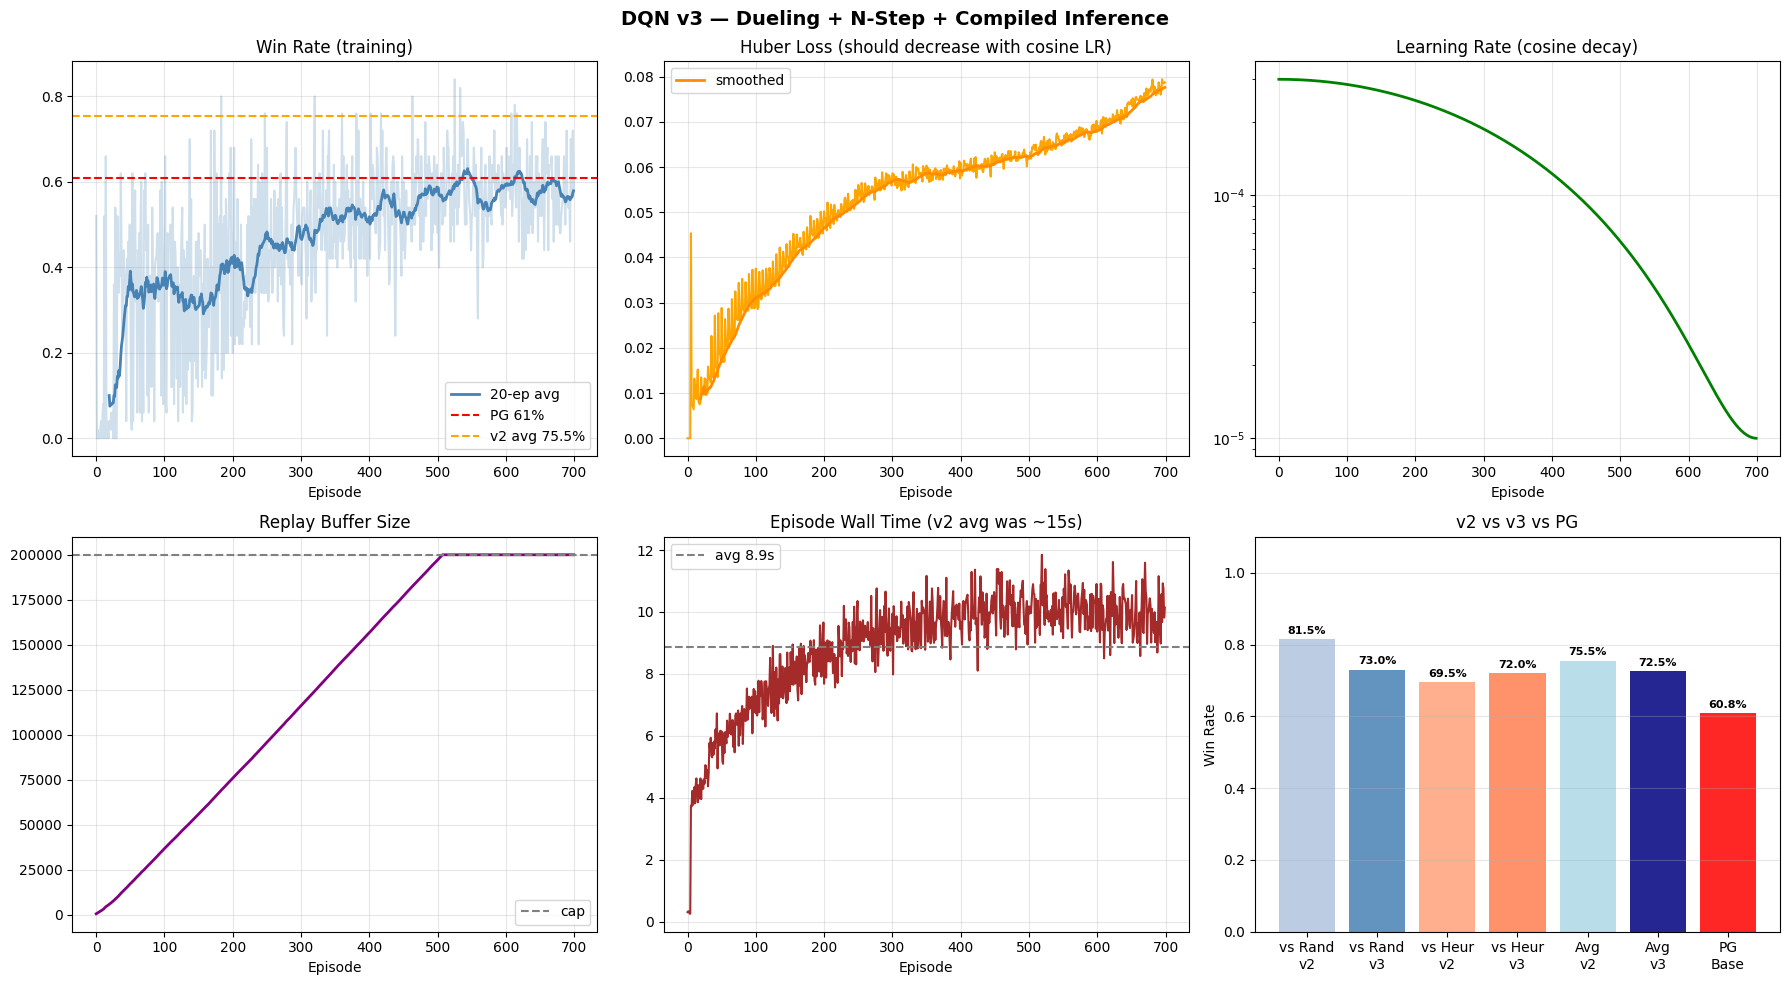


  DQN v3 FINAL SUMMARY
  Episodes       : 700  (n-step=3)
  Total games    : 35,000
  Gradient steps : 139,000
  Training time  : 103.7 min
  Avg ep time    : 8.9s  (v2 was ~15s)
  Buffer fill    : 200,000 / 200,000
  Self-play pool : 12 snapshots

  vs random      : 73.0%  (v2: 81.5%)
  vs heuristic   : 72.0%  (v2: 69.5%)
  vs self-play   : 71.0%
  Average        : 72.5%  (v2: 75.5%  Δ-3.0%)
  vs PG          : +11.7%  (BEATS PG ✓)


In [10]:
# Cell 10: Training Curves and Summary

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('DQN v3 — Dueling + N-Step + Compiled Inference', fontsize=14, fontweight='bold')

eps = log['episode']
W   = 20
smooth = lambda arr, w: np.convolve(arr, np.ones(w)/w, mode='valid')

# Win rate
ax = axes[0,0]
ax.plot(eps, log['win_rate'], alpha=0.25, color='steelblue')
ax.plot(eps[W-1:], smooth(log['win_rate'], W), color='steelblue', lw=2, label=f'{W}-ep avg')
ax.axhline(PG_BASELINE,          color='red',   ls='--', label=f'PG {PG_BASELINE:.0%}')
ax.axhline(V2_RESULTS['avg'],    color='orange',ls='--', label=f'v2 avg {V2_RESULTS["avg"]:.1%}')
ax.set_title('Win Rate (training)'); ax.set_xlabel('Episode'); ax.legend(); ax.grid(alpha=0.3)

# Loss
ax = axes[0,1]
ax.plot(eps, log['loss'], color='orange', lw=1.5)
if len(log['loss']) > W:
    ax.plot(eps[W-1:], smooth(log['loss'], W), color='darkorange', lw=2, label='smoothed')
    ax.legend()
ax.set_title('Huber Loss (should decrease with cosine LR)')
ax.set_xlabel('Episode'); ax.grid(alpha=0.3)

# LR schedule
ax = axes[0,2]
ax.plot(eps, log['lr'], color='green', lw=2)
ax.set_title('Learning Rate (cosine decay)')
ax.set_xlabel('Episode'); ax.set_yscale('log'); ax.grid(alpha=0.3)

# Buffer fill
ax = axes[1,0]
ax.plot(eps, log['buffer_size'], color='purple', lw=2)
ax.axhline(BUFFER_CAP, color='gray', ls='--', label='cap')
ax.set_title('Replay Buffer Size'); ax.set_xlabel('Episode'); ax.legend(); ax.grid(alpha=0.3)

# Episode time
ax = axes[1,1]
ax.plot(eps, log['ep_time'], color='brown', lw=1.5)
ax.axhline(np.mean(log['ep_time']), color='gray', ls='--',
           label=f'avg {np.mean(log["ep_time"]):.1f}s')
ax.set_title('Episode Wall Time (v2 avg was ~15s)'); ax.set_xlabel('Episode')
ax.legend(); ax.grid(alpha=0.3)

# Bar: v2 vs v3 vs PG
ax = axes[1,2]
labels = ['vs Rand\nv2', 'vs Rand\nv3', 'vs Heur\nv2', 'vs Heur\nv3', 'Avg\nv2', 'Avg\nv3', 'PG\nBase']
values = [V2_RESULTS['random'], wr_rand, V2_RESULTS['heuristic'], wr_heur,
          V2_RESULTS['avg'], avg_wr, PG_BASELINE]
colors = ['lightsteelblue','steelblue','lightsalmon','coral',
          'lightblue','navy','red']
bars = ax.bar(labels, values, color=colors, alpha=0.85)
for b, v in zip(bars, values):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.1%}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_ylim(0, 1.1); ax.set_title('v2 vs v3 vs PG')
ax.set_ylabel('Win Rate'); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig_path = REPO_DIR / 'logs' / 'dqn_v3_curves.png'
plt.savefig(str(fig_path), dpi=120, bbox_inches='tight')
if DRIVE_DIR:
    plt.savefig(str(DRIVE_DIR / 'dqn_v3_curves.png'), dpi=120, bbox_inches='tight')
plt.show()

print('\n' + '='*55)
print('  DQN v3 FINAL SUMMARY')
print('='*55)
print(f'  Episodes       : {NUM_EPISODES}  (n-step={N_STEP})')
print(f'  Total games    : {TOTAL_GAMES:,}')
print(f'  Gradient steps : {total_steps:,}')
print(f'  Training time  : {elapsed/60:.1f} min')
print(f'  Avg ep time    : {np.mean(log["ep_time"]):.1f}s  (v2 was ~15s)')
print(f'  Buffer fill    : {len(buf):,} / {BUFFER_CAP:,}')
print(f'  Self-play pool : {len(sp_pool)} snapshots')
print()
print(f'  vs random      : {wr_rand:.1%}  (v2: {V2_RESULTS["random"]:.1%})')
print(f'  vs heuristic   : {wr_heur:.1%}  (v2: {V2_RESULTS["heuristic"]:.1%})')
if wr_self: print(f'  vs self-play   : {wr_self:.1%}')
print(f'  Average        : {avg_wr:.1%}  (v2: {V2_RESULTS["avg"]:.1%}  Δ{delta_v2:+.1%})')
print(f'  vs PG          : {delta_pg:+.1%}  ({"BEATS PG ✓" if delta_pg>0 else "below PG"})')
print('='*55)